# Práctico 2 — Ejercicio 7

Análisis discriminante lineal (LDA) con `scikit-learn`, datos normales bivariados con $\Sigma = C^\top C$, medias $\mu_1 = (0,0)$ y $\mu_2 = (1,1)$, priors iguales.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import train_test_split

rng = np.random.default_rng(42)

# Matriz c_mat
c_mat = np.array([[0.0, -0.23], [0.83, 0.23]])
sigma = c_mat.T @ c_mat
mu1 = np.array([0.0, 0.0])
mu2 = np.array([1.0, 1.0])

print("Σ =\n", sigma)

Σ =
 [[0.6889 0.1909]
 [0.1909 0.1058]]


## (a) Simulación bivariada

Generamos muestras $X \sim \mathcal{N}(\mu_i, \Sigma)$ para cada clase (misma covarianza en ambas).

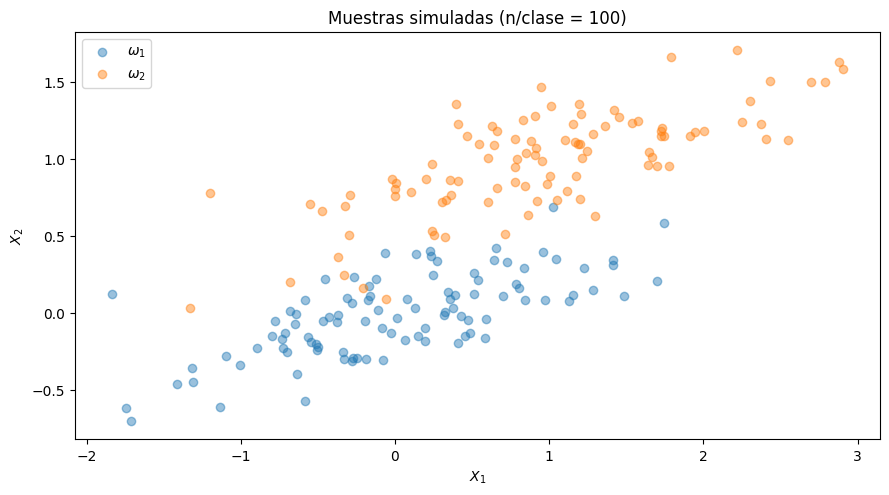

In [2]:
def sample_gaussian(n_per_class, mu_a, mu_b, cov, random_state):
    """n_puntos por clase; etiquetas 0 y 1."""
    xa = random_state.multivariate_normal(mu_a, cov, size=n_per_class)
    xb = random_state.multivariate_normal(mu_b, cov, size=n_per_class)
    X = np.vstack([xa, xb])
    y = np.array([0] * n_per_class + [1] * n_per_class)
    return X, y

n_demo = 100
X_biv, y_biv = sample_gaussian(n_demo, mu1, mu2, sigma, rng)

fig, ax = plt.subplots(figsize=(9, 9))
ax.scatter(X_biv[y_biv == 0, 0], X_biv[y_biv == 0, 1], alpha=0.45, label=r"$\omega_1$")
ax.scatter(X_biv[y_biv == 1, 0], X_biv[y_biv == 1, 1], alpha=0.45, label=r"$\omega_2$")
ax.set_xlabel(r"$X_1$")
ax.set_ylabel(r"$X_2$")
ax.set_title(f"Muestras simuladas (n/clase = {n_demo})")
ax.legend()
ax.set_aspect("equal", adjustable="box")
plt.tight_layout()

## (b) Clasificador LDA usando solo $X_1$

Prior iguales es el valor por defecto de `LinearDiscriminantAnalysis` cuando las frecuencias de clase son iguales. Entrenamos con un solo atributo (primera columna).

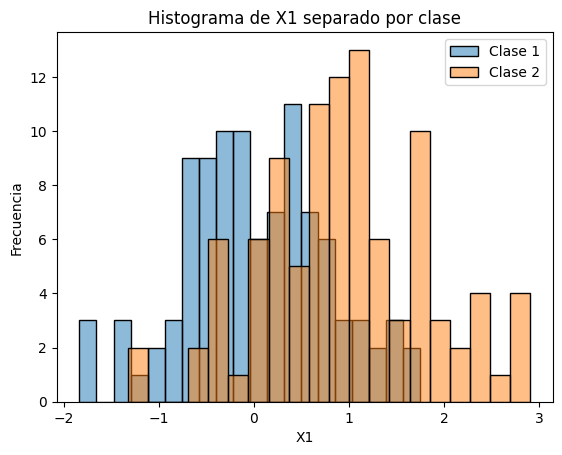

In [3]:
# Primero visualicemos un histograma de los datos separados por clase con Seaborn
sns.histplot(X_biv[y_biv == 0, 0], bins=20, alpha=0.5, label='Clase 1')
sns.histplot(X_biv[y_biv == 1, 0], bins=20, alpha=0.5, label='Clase 2')
plt.xlabel('X1')
plt.ylabel('Frecuencia')
plt.title('Histograma de X1 separado por clase')
plt.legend()
plt.show()

En dos dimensiones, los datos se ven más separables que al verlos por una única feature.

Probemos armar el clasificador y darle un punto en el medio, qué pasa si corremos esta celda varias veces?

In [4]:
n_por_clase = 100
X, y = sample_gaussian(n_por_clase, mu1, mu2, sigma, rng)
X1 = X[:, :1]

lda_1d = LinearDiscriminantAnalysis(priors=(0.5, 0.5))
lda_1d.fit(X1, y)

# Punto nuevo de ejemplo
x_new = np.array([0.5]).reshape(1, -1)
pred = lda_1d.predict(x_new)[0]
proba = lda_1d.predict_proba(x_new)[0]

print(f"Regla discriminante lineal (1D): {lda_1d.coef_} + X1 {lda_1d.intercept_}")
print(f"Clase predicha para x_new = {x_new.ravel()[0]:.2f}:", pred)
print("Probabilidades predichas [P(ω1|x), P(ω2|x)]:", proba)

Regla discriminante lineal (1D): [[1.23448377]] + X1 [-0.68443008]
Clase predicha para x_new = 0.50: 0
Probabilidades predichas [P(ω1|x), P(ω2|x)]: [0.51679073 0.48320927]


## (c) Error empírico post train-test (80 % / 20 %) sobre $X_1$

Para cada $n \in \{100,200,\ldots,10000\}$ generamos $n/2$ puntos por clase, entrenamos LDA en el 80 % y medimos la proporción de errores en el conjunto de test (20 %).

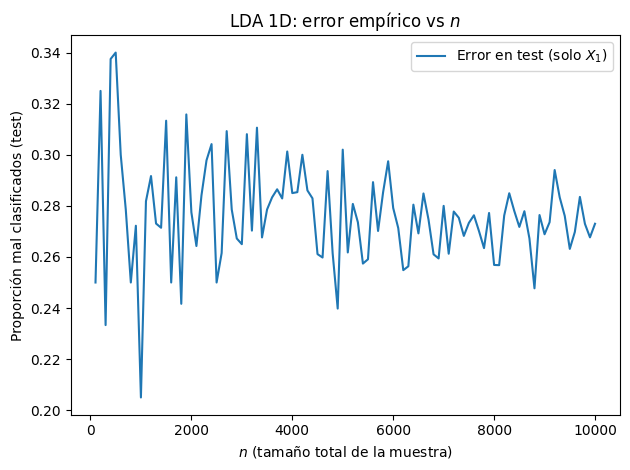

In [5]:
def test_error_lda(X_build, y_build, n_features=1):
    X_train, X_test, y_train, y_test = train_test_split(
        X_build[:, :n_features],
        y_build,
        test_size=0.2,
    )
    clf = LinearDiscriminantAnalysis(priors=(0.5, 0.5))
    clf.fit(X_train, y_train)
    return 1.0 - clf.score(X_test, y_test)

ns = np.arange(100, 10_001, 100)
err_1d = np.empty_like(ns, dtype=float)

for i, n in enumerate(ns):
    half = n // 2
    Xn, yn = sample_gaussian(half, mu1, mu2, sigma, rng)
    error = test_error_lda(Xn, yn, n_features=1)
    err_1d[i] = error

fig, ax = plt.subplots()
ax.plot(ns, err_1d, label="Error en test (solo $X_1$)")
ax.set_xlabel("$n$ (tamaño total de la muestra)")
ax.set_ylabel("Proporción mal clasificados (test)")
ax.set_title("LDA 1D: error empírico vs $n$")
ax.legend()
plt.tight_layout()

## (d) Cota de Bhattacharyya

Para dos normales con la misma covarianza $\Sigma$ y priors $P(\omega_i)$, la distancia de Bhattacharyya (exponente de la cota) es

$$B = \frac{1}{8}(\mu_2 - \mu_1)^\top \Sigma^{-1} (\mu_2 - \mu_1),$$

y una cota sobre la probabilidad de error óptima es

$$P(\text{error}) \leq \sqrt{P(\omega_1)P(\omega_2)}\, e^{-B}.$$

Para **solo $X_1$**, usamos la marginal $\mathcal{N}(\mu_{i,1}, \Sigma_{11})$.

B (solo X1) = 0.181449
Cota Bhattacharyya (1D) P(error) <= 0.417031
B (X1, X2) = 1.416260
Cota Bhattacharyya (2D) P(error) <= 0.121310


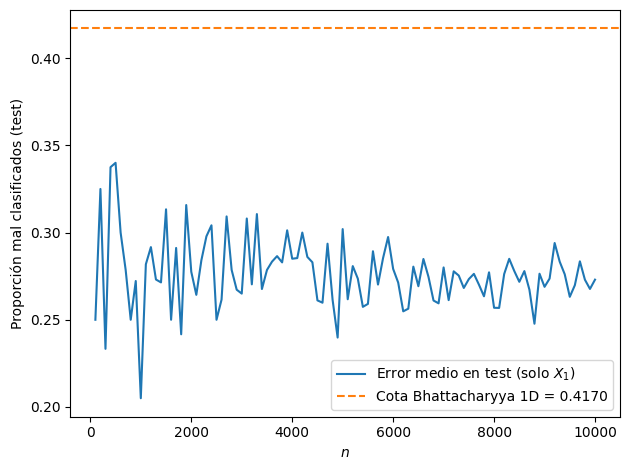

In [6]:
def bhattacharyya_error_bound(mu_a, mu_b, sigma, priors=(0.5, 0.5)):
    """sigma: matriz covarianza (d x d) o escalar varianza en 1D."""
    d = np.asarray(mu_a).size
    delta = np.asarray(mu_b, dtype=float) - np.asarray(mu_a, dtype=float)
    if d == 1:
        v = float(sigma)
        B = (delta.ravel()[0] ** 2) / (8.0 * v)
    else:
        inv = np.linalg.inv(sigma)
        B = 0.125 * float(delta @ inv @ delta)
    p1, p2 = priors
    return np.sqrt(p1 * p2) * np.exp(-B), B


sig11 = sigma[0, 0]
bound_1d, B1 = bhattacharyya_error_bound(np.array([mu1[0]]), np.array([mu2[0]]), sig11)
bound_2d, B2 = bhattacharyya_error_bound(mu1, mu2, sigma)

print(f"B (solo X1) = {B1:.6f}")
print(f"Cota Bhattacharyya (1D) P(error) <= {bound_1d:.6f}")
print(f"B (X1, X2) = {B2:.6f}")
print(f"Cota Bhattacharyya (2D) P(error) <= {bound_2d:.6f}")

fig, ax = plt.subplots()
ax.plot(ns, err_1d, label="Error medio en test (solo $X_1$)")
ax.axhline(bound_1d, color="C1", linestyle="--", label=f"Cota Bhattacharyya 1D = {bound_1d:.4f}")
ax.set_xlabel("$n$")
ax.set_ylabel("Proporción mal clasificados (test)")
ax.legend()
plt.tight_layout()

## (e) Repetir con $X_1$ y $X_2$

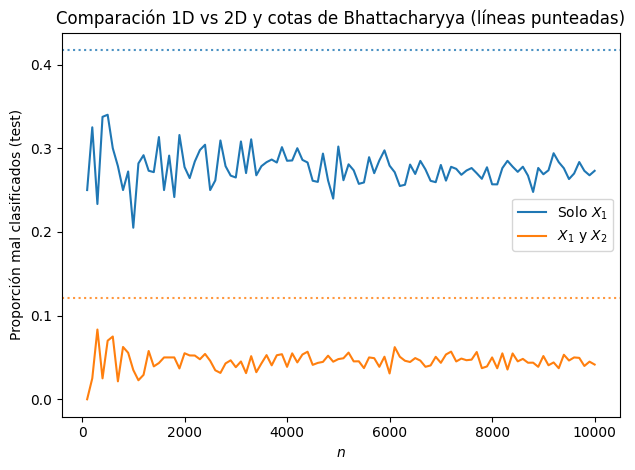

In [7]:
err_2d = np.empty_like(ns, dtype=float)

for i, n in enumerate(ns):
    half = n // 2
    Xn, yn = sample_gaussian(half, mu1, mu2, sigma, rng)
    m = test_error_lda(Xn, yn, n_features=2)
    err_2d[i] = m

fig, ax = plt.subplots()
ax.plot(ns, err_1d, label="Solo $X_1$")
ax.plot(ns, err_2d, label="$X_1$ y $X_2$")
ax.axhline(bound_1d, color="C0", linestyle=":", alpha=0.8)
ax.axhline(bound_2d, color="C1", linestyle=":", alpha=0.8)
ax.set_xlabel("$n$")
ax.set_ylabel("Proporción mal clasificados (test)")
ax.set_title("Comparación 1D vs 2D y cotas de Bhattacharyya (líneas punteadas)")
ax.legend()
plt.tight_layout()

## (f) Análisis

- **Cota vs datos:** La cota de Bhattacharyya acota el error de Bayes bajo el modelo generativo verdadero; el error en test estimado con LDA fluctúa alrededor de ese régimen y, con $n$ grande, suele acercarse al error bayesiano si el modelo encaja (aquí las clases son normales con misma $\Sigma$, que es exactamente lo que asume LDA).
- **¿Aumentar la dimensión empeora siempre el error empírico?** No. Para este problema, la distribución marginal de $X_1$ solapa más las clases que el par $(X_1,X_2)$: el error bayesiano en 2D es menor que en 1D (la cota en 2D es más apretada / $B$ es mayor). Con $n$ suficientemente grande, el error empírico con dos características **tiende a ser menor** que con una sola.
- **Curva de fenómeno para $n$ pequeños:** Con conjuntos finitos pequeños, el modelo 2D tiene **más parámetros** que estimar. Para $n$ muy chico la varianza del error de estimación en test puede hacer que en **alguna corrida** el 2D vea más error que el 1D, pero **no hay una regla** de que “más dimensión ⇒ siempre peor error empírico”: depende de si la información extra domina frente al ruido de estimación y de la maldición de la dimensionalidad cuando $n$ es pequeño frente a $d$.

Finalmente, *no es cierto* que para todo conjunto finito el error empírico suba al aumentar $d$; puede bajar cuando la nueva variable es discriminativa y $n$ alcanza para estimar bien.